In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
df = pd.read_csv("C:/python_projects/hack-292e04fe-neurohub/dataset_energy.csv")
df.head(5)

,ID,Статистическое время,Средняя скорость ветра(m/s),Нормализованная активная мощность,Средняя температура окружающей среды(°C)
0,1,2023-03-11 0:00:00,6.62,0.37,15.52
1,2,2023-03-11 0:10:00,6.70,0.39,15.38
2,3,2023-03-11 0:20:00,7.14,0.44,15.43
3,4,2023-03-11 0:30:00,7.82,0.50,15.41
4,5,2023-03-11 0:40:00,7.62,0.49,15.42


In [3]:
df["Статистическое время"] = pd.to_datetime(
    df["Статистическое время"]
)

df = df.sort_values("Статистическое время")

df = df.set_index("Статистическое время")

df.head()

,ID,Средняя скорость ветра(m/s),Нормализованная активная мощность,Средняя температура окружающей среды(°C)
Статистическое время,,,,
2023-03-11 00:00:00,1,6.62,0.37,15.52
2023-03-11 00:10:00,2,6.70,0.39,15.38
2023-03-11 00:20:00,3,7.14,0.44,15.43
2023-03-11 00:30:00,4,7.82,0.50,15.41
2023-03-11 00:40:00,5,7.62,0.49,15.42


In [4]:
y = df["Нормализованная активная мощность"].astype(float)

y.head()

Статистическое время
2023-03-11 00:00:00    0.37
2023-03-11 00:10:00    0.39
2023-03-11 00:20:00    0.44
2023-03-11 00:30:00    0.50
2023-03-11 00:40:00    0.49
Name: Нормализованная активная мощность, dtype: float64

In [5]:
print("Начало:", y.index.min())
print("Конец:", y.index.max())
print("Количество наблюдений:", len(y))

print("\nШаг:")
print(y.index.to_series().diff().value_counts().head(10))

Начало: 2023-03-11 00:00:00
Конец: 2026-01-31 23:50:00
Количество наблюдений: 149499

Шаг:
Статистическое время
0 days 00:10:00    149320
0 days 00:20:00        58
0 days 00:30:00        22
0 days 00:50:00        11
0 days 01:00:00        10
0 days 00:40:00         9
0 days 01:10:00         9
0 days 02:40:00         3
0 days 01:50:00         3
0 days 03:40:00         3
Name: count, dtype: int64


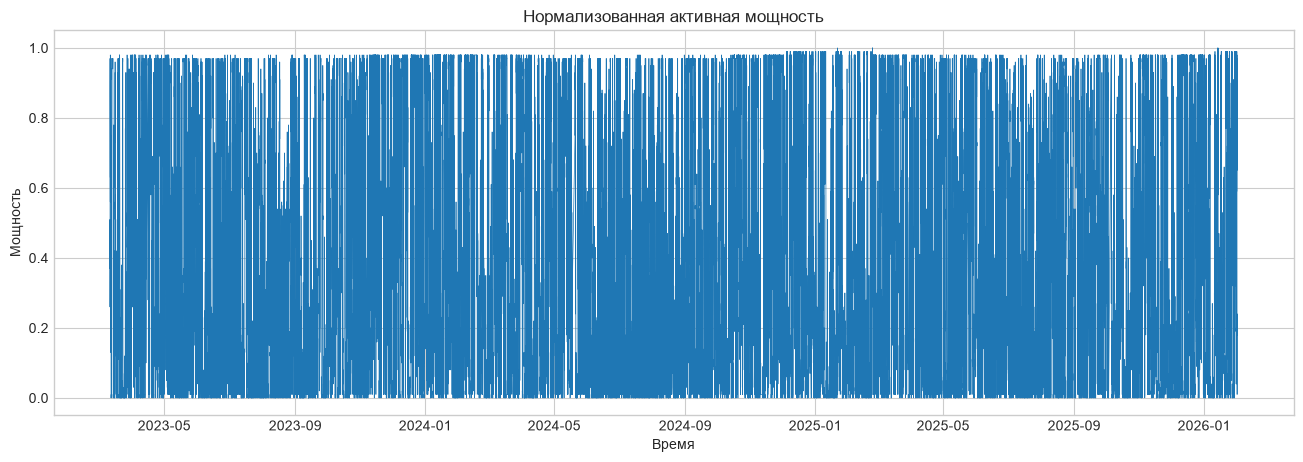

In [6]:
plt.figure(figsize=(16, 5))

plt.plot(y, linewidth=0.5)

plt.title("Нормализованная активная мощность")
plt.xlabel("Время")
plt.ylabel("Мощность")

plt.show()

In [7]:
train_size = int(len(y) * 0.8)

train = y.iloc[:train_size]
test = y.iloc[train_size:]

print("Train:", train.shape)
print("Test:", test.shape)

print("\nTrain:")
print(train.index.min(), "→", train.index.max())

print("\nTest:")
print(test.index.min(), "→", test.index.max())


Train: (119599,)
Test: (29900,)

Train:
2023-03-11 00:00:00 → 2025-07-05 12:30:00

Test:
2025-07-05 12:40:00 → 2026-01-31 23:50:00


In [8]:
result = adfuller(train.dropna())

print("ADF statistic:", result[0])
print("p-value:", result[1])


ADF statistic: -33.609654197259545
p-value: 0.0


In [9]:
seasonal_period = 144

print("Сезонный период:", seasonal_period)
print("Это:", seasonal_period * 10 / 60, "часов")


Сезонный период: 144
Это: 24.0 часов


In [ ]:
model = SARIMAX(
    train,  
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 144),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(
    disp=False
)

print(model_fit.summary())


In [ ]:
forecast = model_fit.get_forecast(
    steps=len(test)
)

y_pred = forecast.predicted_mean

y_pred.index = test.index

y_pred.head()


In [ ]:
y_pred_clipped = y_pred.clip(0, 1)


In [ ]:
mae = mean_absolute_error(
    test,
    y_pred_clipped
)

print("MAE:", mae)


In [ ]:
rmse = np.sqrt(
    mean_squared_error(
        test,
        y_pred_clipped
    )
)

print("RMSE:", rmse)


In [ ]:
mask = test != 0

mape = np.mean(
    np.abs(
        (test[mask] - y_pred_clipped[mask])
        / test[mask]
    )
) * 100

print("MAPE:", mape, "%")


In [ ]:
plt.figure(figsize=(16, 6))

plt.plot(
    test.index,
    test,
    label="Реальная мощность",
    linewidth=1
)

plt.plot(
    test.index,
    y_pred_clipped,
    label="SARIMA прогноз",
    linewidth=1
)

plt.title("SARIMA: реальная и прогнозируемая мощность")

plt.xlabel("Время")
plt.ylabel("Нормализованная мощность")

plt.legend()

plt.show()


In [ ]:
n = 144 * 7

plt.figure(figsize=(16, 6))

plt.plot(
    test.index[-n:],
    test.iloc[-n:],
    label="Реальная мощность",
    linewidth=1
)

plt.plot(
    test.index[-n:],
    y_pred_clipped.iloc[-n:],
    label="SARIMA",
    linewidth=1
)

plt.title("SARIMA — последние 7 дней")

plt.xlabel("Время")
plt.ylabel("Нормализованная мощность")

plt.legend()

plt.show()


In [ ]:
residuals = test - y_pred_clipped

plt.figure(figsize=(16, 5))

plt.plot(
    residuals,
    linewidth=0.5
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Остатки SARIMA")

plt.xlabel("Время")
plt.ylabel("Ошибка")

plt.show()


In [ ]:
results = pd.DataFrame({
    "actual": test,
    "prediction": y_pred_clipped,
    "residual": test - y_pred_clipped
})

results.head()

results.to_csv(
    "sarima_predictions.csv"
)

In [ ]:
import itertools

p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1, 2]

P_values = [0, 1]
D_values = [0, 1]
Q_values = [0, 1]

results_grid = []

for p, d, q in itertools.product(
    p_values,
    d_values,
    q_values
):
    
    for P, D, Q in itertools.product(
        P_values,
        D_values,
        Q_values
    ):
        
        order = (p, d, q)
        seasonal_order = (
            P, D, Q, 144
        )
        
        print(
            "Testing:",
            order,
            seasonal_order
        )
        
        try:
            model = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            
            fitted = model.fit(
                disp=False
            )
            
            pred = fitted.get_forecast(
                steps=len(test)
            ).predicted_mean
            
            pred = pred.clip(0, 1)
            
            mae = mean_absolute_error(
                test,
                pred
            )
            
            rmse = np.sqrt(
                mean_squared_error(
                    test,
                    pred
                )
            )
            
            results_grid.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "AIC": fitted.aic,
                "MAE": mae,
                "RMSE": rmse
            })
            
        except Exception as e:
            
            print("Ошибка:", e)


In [ ]:
search_train = train.iloc[-144 * 30:]

print(search_train.shape)
print(search_train.index.min())
print(search_train.index.max())


In [ ]:
results_grid = pd.DataFrame(
    results_grid
)

results_grid.sort_values(
    "MAE"
).head(10)


In [ ]:
results_grid.sort_values(
    "RMSE"
).head(10)


In [ ]:
results_grid.sort_values(
    "AIC"
).head(10)


In [ ]:
order = (1, 1, 2)
seasonal_order = (1, 1, 1, 144)


In [ ]:
final_model = SARIMAX(
    train,
    order=(1, 1, 2),
    seasonal_order=(1, 1, 1, 144),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fit = final_model.fit(
    disp=False
)

print(final_fit.summary())


In [ ]:
final_forecast = final_fit.get_forecast(
    steps=len(test)
)

final_pred = final_forecast.predicted_mean

final_pred = final_pred.clip(0, 1)

final_pred.index = test.index


In [ ]:
final_mae = mean_absolute_error(
    test,
    final_pred
)

final_rmse = np.sqrt(
    mean_squared_error(
        test,
        final_pred
    )
)

print(f"MAE  = {final_mae:.5f}")
print(f"RMSE = {final_rmse:.5f}")


In [ ]:
plt.figure(figsize=(16, 6))

plt.plot(
    test.index,
    test,
    label="Факт",
    linewidth=1
)

plt.plot(
    test.index,
    final_pred,
    label="SARIMA",
    linewidth=1
)

plt.title(
    "Прогноз нормализованной активной мощности — SARIMA"
)

plt.xlabel("Время")
plt.ylabel("Нормализованная мощность")

plt.legend()

plt.show()
